In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

In [2]:
data=pd.read_csv("ss.csv")
data.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 373 entries, 0 to 372
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                373 non-null    int64  
 1   Gender                   373 non-null    object 
 2   Age                      373 non-null    int64  
 3   Occupation               373 non-null    object 
 4   Sleep Duration           373 non-null    float64
 5   Quality of Sleep         373 non-null    int64  
 6   Physical Activity Level  373 non-null    int64  
 7   Stress Level             373 non-null    int64  
 8   BMI Category             373 non-null    object 
 9   Blood Pressure           373 non-null    object 
 10  Heart Rate               373 non-null    int64  
 11  Daily Steps              373 non-null    int64  
 12  Sleep Disorder           154 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.0+ KB


In [4]:
data.shape

(373, 13)

In [5]:
data.describe()

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,373.000000,373.000000,373.000000,373.000000,373.000000,373.000000,373.000000,373.000000
mean,187.000000,42.139410,7.129491,7.308311,59.128686,5.391421,70.171582,6816.353887
std,107.820066,8.640793,0.795139,1.195359,20.842589,1.772590,4.139704,1620.060932
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.000000,35.000000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.000000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.000000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,373.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


In [6]:
data.isnull().sum()

Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64

# Handle Missing Values

In [7]:
data["Sleep Disorder"] = data["Sleep Disorder"].fillna("None")

In [10]:
data["Sleep Disorder"].value_counts()

Sleep Disorder
None           219
Sleep Apnea     77
Insomnia        77
Name: count, dtype: int64

In [11]:
data.duplicated().sum()

np.int64(0)

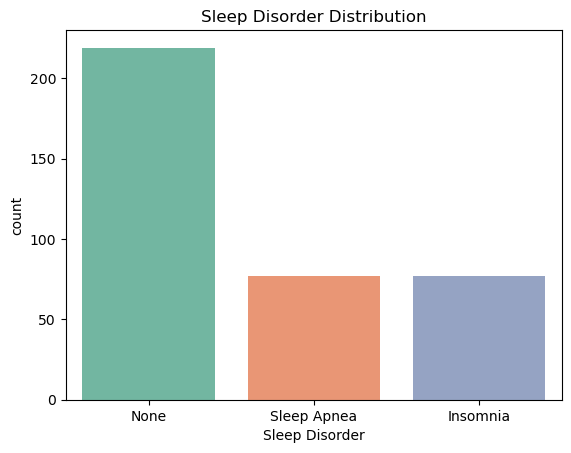

In [12]:
sns.countplot(x="Sleep Disorder", data=data, palette="Set2")
plt.title("Sleep Disorder Distribution")
plt.show()

In [15]:
X = data[[
    "Age",
    "Sleep Duration",
    "Quality of Sleep",
    "Physical Activity Level",
    "Stress Level",
    "Heart Rate",
    "Daily Steps"
]]
X.head()

,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
0,27,6.1,6,42,6,77,4200
1,28,6.2,6,60,8,75,10000
2,28,6.2,6,60,8,75,10000
3,28,5.9,4,30,8,85,3000
4,28,5.9,4,30,8,85,3000


In [16]:
y = data["Sleep Disorder"]
y.head()

0           None
1           None
2           None
3    Sleep Apnea
4    Sleep Apnea
Name: Sleep Disorder, dtype: object

In [18]:
# train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [32]:
# feature scaling


from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
import pickle
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

In [41]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000,class_weight="balanced",
    random_state=42
)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [28]:
y_pred = model.predict(X_test)

In [42]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")
print(classification_report(y_test, y_pred))


Model Accuracy: 89.33 %
              precision    recall  f1-score   support

    Insomnia       0.78      0.82      0.80        17
        None       0.93      0.98      0.95        41
 Sleep Apnea       0.93      0.76      0.84        17

    accuracy                           0.89        75
   macro avg       0.88      0.85      0.86        75
weighted avg       0.90      0.89      0.89        75



In [36]:
from sklearn.metrics import classification_report, confusion_matrix

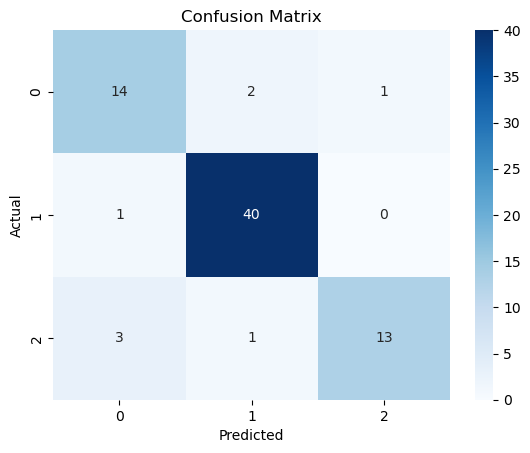

In [38]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [43]:
with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Model saved successfully!")
    

Model saved successfully!


In [49]:
sample = [[25, 8, 8, 60, 3, 70, 8000]]

sample_scaled = scaler.transform(sample)

print(model.classes_)
print(model.predict_proba(sample_scaled))
print(model.predict(sample_scaled))

['Insomnia' 'None' 'Sleep Apnea']
[[0. 0. 1.]]
['Sleep Apnea']


In [51]:
print(data.groupby("Sleep Disorder")[[
    "Age",
    "Sleep Duration",
    "Quality of Sleep",
    "Physical Activity Level",
    "Stress Level",
    "Heart Rate",
    "Daily Steps"
]].mean())

                      Age  Sleep Duration  Quality of Sleep  \
Sleep Disorder                                                
Insomnia        43.519481        6.589610          6.532468   
None            39.036530        7.358447          7.625571   
Sleep Apnea     49.584416        7.018182          7.181818   

                Physical Activity Level  Stress Level  Heart Rate  Daily Steps  
Sleep Disorder                                                                  
Insomnia                      46.818182      5.870130   70.467532  5901.298701  
None                          57.949772      5.114155   69.018265  6852.968037  
Sleep Apnea                   74.792208      5.701299   73.155844  7627.272727  
